In [1]:
# 1. Import Libraries And Configure File Paths

from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

from pgmpy.estimators import HillClimbSearch, BayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.inference import VariableElimination

warnings.filterwarnings("ignore", category=FutureWarning)

# -----------------------------------------------------------------------------
# CHANGE THIS PATH IF YOUR MIMIC-IV FILES ARE STORED ELSEWHERE.
# -----------------------------------------------------------------------------
HOSP_FOLDER = Path(r"C:\Users\Shalika\Desktop\MIMIC-IV")

# All generated outputs are saved here.
OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)
TABLE_DIR.mkdir(exist_ok=True)

ANALYTIC_DATA_FILE = OUTPUT_DIR / "covid_analysis_table.csv"


def find_file(folder: Path, filename: str) -> Path:
    """Find either an uncompressed CSV or a .csv.gz MIMIC-IV table."""
    possible_paths = [
        folder / filename,
        folder / f"{filename}.gz",
    ]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"Could not find {filename} or {filename}.gz in {folder}"
    )


print("=" * 80)
print("HI823 FINAL PROJECT")
print("COVID-19 Mortality Prediction with LASSO and Bayesian Networks")
print("=" * 80)
print(f"MIMIC-IV folder: {HOSP_FOLDER}")
print(f"Output folder:   {OUTPUT_DIR.resolve()}")

HI823 FINAL PROJECT
COVID-19 Mortality Prediction with LASSO and Bayesian Networks
MIMIC-IV folder: C:\Users\Shalika\Desktop\MIMIC-IV
Output folder:   C:\Users\Shalika\outputs


C:\Users\Shalika\anaconda3\envs\bayesnet\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [2]:
# 2. Load Mimic-Iv Tables

print("\n[2] Loading MIMIC-IV patient and admission tables...")

patients = pd.read_csv(
    find_file(HOSP_FOLDER, "patients.csv"),
    usecols=[
        "subject_id",
        "gender",
        "anchor_age",
        "anchor_year",
        "anchor_year_group",
        "dod",
    ],
)

admissions = pd.read_csv(
    find_file(HOSP_FOLDER, "admissions.csv"),
    usecols=[
        "subject_id",
        "hadm_id",
        "admittime",
        "dischtime",
        "deathtime",
        "admission_type",
        "admission_location",
        "discharge_location",
        "insurance",
        "marital_status",
        "race",
        "hospital_expire_flag",
    ],
)

for column in ["admittime", "dischtime", "deathtime"]:
    admissions[column] = pd.to_datetime(admissions[column], errors="coerce")

patients["dod"] = pd.to_datetime(patients["dod"], errors="coerce")

print("Patients table shape:", patients.shape)
print("Admissions table shape:", admissions.shape)


[2] Loading MIMIC-IV patient and admission tables...
Patients table shape: (364627, 6)
Admissions table shape: (546028, 12)


In [3]:
# 3. Identify The Covid-19 Cohort

print("\n[3] Identifying COVID-19 admissions using ICD-10-CM U07.1...")

diagnoses = pd.read_csv(
    find_file(HOSP_FOLDER, "diagnoses_icd.csv"),
    dtype={
        "subject_id": "int64",
        "hadm_id": "int64",
        "seq_num": "Int64",
        "icd_code": "string",
        "icd_version": "Int64",
    },
)

diagnoses["icd_code_clean"] = (
    diagnoses["icd_code"]
    .str.upper()
    .str.replace(".", "", regex=False)
    .str.strip()
)

covid_diagnoses = diagnoses[
    (diagnoses["icd_version"] == 10)
    & (diagnoses["icd_code_clean"] == "U071")
].copy()

covid_admission_ids = set(covid_diagnoses["hadm_id"].dropna().tolist())

if len(covid_admission_ids) == 0:
    raise ValueError(
        "No admissions with ICD-10-CM U07.1 were found. "
        "Check your MIMIC-IV files and version."
    )

print("COVID-19 admissions found:", len(covid_admission_ids))

# Confirm the ICD-10 description from the dictionary.
diagnosis_dictionary = pd.read_csv(
    find_file(HOSP_FOLDER, "d_icd_diagnoses.csv"),
    dtype={"icd_code": "string", "icd_version": "Int64"},
)

diagnosis_dictionary["icd_code_clean"] = (
    diagnosis_dictionary["icd_code"]
    .str.upper()
    .str.replace(".", "", regex=False)
    .str.strip()
)

covid_description = diagnosis_dictionary[
    (diagnosis_dictionary["icd_version"] == 10)
    & (diagnosis_dictionary["icd_code_clean"] == "U071")
]

if not covid_description.empty:
    print("COVID-19 diagnosis dictionary match:")
    print(covid_description.to_string(index=False))


[3] Identifying COVID-19 admissions using ICD-10-CM U07.1...
COVID-19 admissions found: 3978
COVID-19 diagnosis dictionary match:
icd_code  icd_version long_title icd_code_clean
    U071           10   COVID-19           U071


In [4]:
# 4. Create Demographic And Hospital Variables

print("\n[4] Creating cohort demographics and hospital outcomes...")

cohort = admissions[admissions["hadm_id"].isin(covid_admission_ids)].copy()

cohort = cohort.merge(
    patients,
    on="subject_id",
    how="left",
    validate="many_to_one",
)

cohort["admission_year"] = cohort["admittime"].dt.year

cohort["age"] = (
    cohort["anchor_age"]
    + cohort["admission_year"]
    - cohort["anchor_year"]
)

cohort["hospital_los_days"] = (
    cohort["dischtime"] - cohort["admittime"]
).dt.total_seconds() / 86400

cohort["female"] = (
    cohort["gender"]
    .astype("string")
    .str.upper()
    .eq("F")
    .astype("int8")
)

cohort["in_hospital_mortality"] = (
    cohort["hospital_expire_flag"].fillna(0).astype("int8")
)

cohort["covid_diagnosis"] = 1

print("COVID cohort shape:", cohort.shape)
print("Unique patients:", cohort["subject_id"].nunique())


[4] Creating cohort demographics and hospital outcomes...
COVID cohort shape: (3978, 23)
Unique patients: 3620


In [6]:
# 5. Create Comorbidity Variables

print("\n[5] Creating ICD-10 comorbidity indicators...")

COMORBIDITY_CODES = {
    "hypertension": ["I10", "I11", "I12", "I13", "I15"],
    "diabetes": ["E08", "E09", "E10", "E11", "E13"],
    "obesity": ["E66"],
    "copd": ["J40", "J41", "J42", "J43", "J44"],
    "asthma": ["J45"],
    "chronic_kidney_disease": ["N18"],
    "heart_failure": ["I50"],
    "coronary_artery_disease": ["I20", "I21", "I22", "I23", "I24", "I25"],
    "cancer": ["C"],
    "liver_disease": ["K70", "K71", "K72", "K73", "K74", "K75", "K76"],
    "cerebrovascular_disease": [
        "I60", "I61", "I62", "I63", "I64",
        "I65", "I66", "I67", "I68", "I69",
    ],
    "dementia": ["F00", "F01", "F02", "F03", "G30"],
}

covid_diagnosis_rows = diagnoses[
    diagnoses["hadm_id"].isin(covid_admission_ids)
].copy()

for condition, prefixes in COMORBIDITY_CODES.items():
    condition_mask = covid_diagnosis_rows["icd_code_clean"].str.startswith(
        tuple(prefixes),
        na=False,
    )

    admissions_with_condition = set(
        covid_diagnosis_rows.loc[condition_mask, "hadm_id"]
    )

    cohort[condition] = (
        cohort["hadm_id"].isin(admissions_with_condition).astype("int8")
    )

comorbidity_columns = list(COMORBIDITY_CODES.keys())
cohort["comorbidity_count"] = cohort[comorbidity_columns].sum(axis=1)

print("Created comorbidity variables:")
print(comorbidity_columns)


[5] Creating ICD-10 comorbidity indicators...
Created comorbidity variables:
['hypertension', 'diabetes', 'obesity', 'copd', 'asthma', 'chronic_kidney_disease', 'heart_failure', 'coronary_artery_disease', 'cancer', 'liver_disease', 'cerebrovascular_disease', 'dementia']


In [7]:
# 6. Extract First-24-Hour Laboratory Values

print("\n[6] Identifying laboratory item IDs...")

lab_dictionary = pd.read_csv(
    find_file(HOSP_FOLDER, "d_labitems.csv"),
    dtype={"itemid": "int64"},
)

LAB_PATTERNS = {
    "wbc": r"white blood cells|\bwbc\b",
    "hemoglobin": r"\bhemoglobin\b",
    "platelets": r"platelet count|\bplatelets\b",
    "creatinine": r"\bcreatinine\b",
    "bun": r"urea nitrogen|\bbun\b",
    "glucose": r"\bglucose\b",
    "sodium": r"\bsodium\b",
    "potassium": r"\bpotassium\b",
    "bicarbonate": r"\bbicarbonate\b|total co2",
    "lactate": r"\blactate\b|lactic acid",
    "crp": r"c-reactive protein|\bcrp\b",
    "ferritin": r"\bferritin\b",
    "d_dimer": r"d-dimer|d dimer",
    "lymphocytes": r"\blymphocytes\b",
    "neutrophils": r"\bneutrophils\b",
    "alt": r"alanine aminotransferase|\balt\b",
    "ast": r"aspartate aminotransferase|\bast\b",
    "total_bilirubin": r"bilirubin, total|total bilirubin",
}

selected_lab_frames = []

for lab_name, pattern in LAB_PATTERNS.items():
    matches = lab_dictionary[
        lab_dictionary["label"]
        .astype("string")
        .str.contains(pattern, case=False, regex=True, na=False)
    ].copy()

    # Prefer blood/serum/plasma results when possible.
    if "fluid" in matches.columns:
        blood_matches = matches[
            matches["fluid"]
            .astype("string")
            .str.contains(
                "blood|serum|plasma",
                case=False,
                regex=True,
                na=False,
            )
        ]
        if not blood_matches.empty:
            matches = blood_matches

    selected = (
        matches[["itemid"]]
        .drop_duplicates()
        .assign(lab_name=lab_name)
    )
    selected_lab_frames.append(selected)

selected_lab_items = pd.concat(selected_lab_frames, ignore_index=True)
selected_lab_itemids = set(selected_lab_items["itemid"].tolist())

print("Selected laboratory item IDs:", len(selected_lab_itemids))

# Build first-24-hour windows.
lab_windows = cohort[["subject_id", "hadm_id", "admittime"]].copy()
lab_windows["window_end"] = lab_windows["admittime"] + pd.Timedelta(hours=24)

retained_lab_chunks = []
lab_columns = [
    "subject_id",
    "hadm_id",
    "itemid",
    "charttime",
    "valuenum",
    "valueuom",
]

print("Reading labevents.csv in chunks. This is the longest data-processing step...")

for chunk_number, chunk in enumerate(
    pd.read_csv(
        find_file(HOSP_FOLDER, "labevents.csv"),
        usecols=lab_columns,
        chunksize=1_000_000,
        low_memory=False,
    ),
    start=1,
):
    chunk = chunk[
        chunk["hadm_id"].isin(covid_admission_ids)
        & chunk["itemid"].isin(selected_lab_itemids)
    ].copy()

    if chunk.empty:
        continue

    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")
    chunk["valuenum"] = pd.to_numeric(chunk["valuenum"], errors="coerce")
    chunk = chunk.dropna(subset=["hadm_id", "charttime", "valuenum"])

    chunk = chunk.merge(
        lab_windows,
        on=["subject_id", "hadm_id"],
        how="inner",
    )

    chunk = chunk[
        (chunk["charttime"] >= chunk["admittime"])
        & (chunk["charttime"] <= chunk["window_end"])
    ]

    chunk = chunk.merge(selected_lab_items, on="itemid", how="inner")

    retained_lab_chunks.append(
        chunk[
            [
                "subject_id",
                "hadm_id",
                "charttime",
                "itemid",
                "lab_name",
                "valuenum",
                "valueuom",
            ]
        ]
    )

    if chunk_number % 10 == 0:
        print(f"  Processed {chunk_number} chunks")

if retained_lab_chunks:
    covid_labs = pd.concat(retained_lab_chunks, ignore_index=True)
else:
    covid_labs = pd.DataFrame()

del retained_lab_chunks
gc.collect()

print("Retained first-24-hour laboratory rows:", covid_labs.shape)

if not covid_labs.empty:
    covid_labs = covid_labs.sort_values(
        ["hadm_id", "lab_name", "charttime"]
    )

    lab_summary = (
        covid_labs
        .groupby(["subject_id", "hadm_id", "lab_name"])["valuenum"]
        .agg(
            first="first",
            minimum="min",
            maximum="max",
            mean="mean",
        )
        .reset_index()
    )

    lab_summary_wide = lab_summary.pivot(
        index=["subject_id", "hadm_id"],
        columns="lab_name",
        values=["first", "minimum", "maximum", "mean"],
    )

    lab_summary_wide.columns = [
        f"first24h_{statistic}_{lab_name}"
        for statistic, lab_name in lab_summary_wide.columns
    ]

    lab_summary_wide = lab_summary_wide.reset_index()

    cohort = cohort.merge(
        lab_summary_wide,
        on=["subject_id", "hadm_id"],
        how="left",
    )


[6] Identifying laboratory item IDs...
Selected laboratory item IDs: 72
Reading labevents.csv in chunks. This is the longest data-processing step...
  Processed 10 chunks
  Processed 20 chunks
  Processed 30 chunks
  Processed 40 chunks
  Processed 50 chunks
  Processed 60 chunks
  Processed 70 chunks
  Processed 80 chunks
  Processed 90 chunks
  Processed 100 chunks
  Processed 110 chunks
  Processed 120 chunks
  Processed 130 chunks
  Processed 140 chunks
  Processed 150 chunks
Retained first-24-hour laboratory rows: (66360, 7)


In [8]:
# 7. Build The Final Analytical Dataset

print("\n[7] Building the final admission-level analytical dataset...")

base_columns = [
    "subject_id",
    "hadm_id",
    "admittime",
    "dischtime",
    "admission_year",
    "age",
    "gender",
    "female",
    "race",
    "insurance",
    "marital_status",
    "admission_type",
    "admission_location",
    "discharge_location",
    "covid_diagnosis",
    "hospital_los_days",
    "in_hospital_mortality",
    "comorbidity_count",
]

lab_columns_final = [
    column for column in cohort.columns if column.startswith("first24h_")
]

final_columns = list(
    dict.fromkeys(
        column
        for column in (base_columns + comorbidity_columns + lab_columns_final)
        if column in cohort.columns
    )
)

covid_table = cohort[final_columns].copy()

covid_table = (
    covid_table
    .drop_duplicates(subset=["subject_id", "hadm_id"])
    .sort_values(["subject_id", "admittime"])
    .reset_index(drop=True)
)

print("Final table shape:", covid_table.shape)
print("Unique patients:", covid_table["subject_id"].nunique())
print("Unique admissions:", covid_table["hadm_id"].nunique())

covid_table.to_csv(ANALYTIC_DATA_FILE, index=False)
print("Saved analytical table to:", ANALYTIC_DATA_FILE)


[7] Building the final admission-level analytical dataset...
Final table shape: (3978, 102)
Unique patients: 3620
Unique admissions: 3978
Saved analytical table to: outputs\covid_analysis_table.csv


In [10]:
# 8. Descriptive Statistics

print("\n[8] Generating descriptive statistics...")

binary_vars = [
    "female",
    "hypertension",
    "diabetes",
    "obesity",
    "copd",
    "asthma",
    "chronic_kidney_disease",
    "heart_failure",
    "coronary_artery_disease",
    "cancer",
    "liver_disease",
    "cerebrovascular_disease",
    "dementia",
    "in_hospital_mortality",
]

binary_summary = []
for variable in binary_vars:
    if variable in covid_table.columns:
        n = covid_table[variable].sum()
        percent = covid_table[variable].mean() * 100
        binary_summary.append(
            {
                "Characteristic": variable,
                "n": int(n),
                "Percent": round(percent, 1),
            }
        )

binary_summary = pd.DataFrame(binary_summary)

continuous_vars = [
    "age",
    "hospital_los_days",
    "comorbidity_count",
    "first24h_first_wbc",
    "first24h_first_creatinine",
    "first24h_first_glucose",
    "first24h_first_potassium",
    "first24h_first_sodium",
    "first24h_first_platelets",
    "first24h_first_hemoglobin",
]

continuous_summary = []
for variable in continuous_vars:
    if variable in covid_table.columns:
        series = covid_table[variable].dropna()
        continuous_summary.append(
            {
                "Characteristic": variable,
                "N_nonmissing": int(series.shape[0]),
                "Mean": round(series.mean(), 2),
                "SD": round(series.std(), 2),
                "Median": round(series.median(), 2),
                "Q1": round(series.quantile(0.25), 2),
                "Q3": round(series.quantile(0.75), 2),
            }
        )

continuous_summary = pd.DataFrame(continuous_summary)

binary_summary.to_csv(TABLE_DIR / "Table1_Binary_Characteristics.csv", index=False)
continuous_summary.to_csv(TABLE_DIR / "Table1_Continuous_Characteristics.csv", index=False)

print("\nBinary characteristics:")
print(binary_summary.to_string(index=False))
print("\nContinuous characteristics:")
print(continuous_summary.to_string(index=False))


[8] Generating descriptive statistics...

Binary characteristics:
         Characteristic    n  Percent
                 female 1921     48.3
           hypertension 2338     58.8
               diabetes 1357     34.1
                obesity  669     16.8
                   copd  403     10.1
                 asthma  427     10.7
 chronic_kidney_disease  946     23.8
          heart_failure  740     18.6
coronary_artery_disease  863     21.7
                 cancer  461     11.6
          liver_disease  465     11.7
cerebrovascular_disease  320      8.0
               dementia  348      8.7
  in_hospital_mortality  412     10.4

Continuous characteristics:
           Characteristic  N_nonmissing   Mean    SD  Median     Q1    Q3
                      age          3978  63.50 18.08   65.00  52.00  77.0
        hospital_los_days          3978  10.79 15.06    6.02   2.81  12.5
        comorbidity_count          3978   2.35  1.75    2.00   1.00   4.0
       first24h_first_wbc          323

In [11]:
# 9. Define Analysis Variables and Temporal Tiers

print("\n[9] Defining variables and temporal tiers...")

outcome = "in_hospital_mortality"

tier_0 = [
    "age",
    "female"
]

tier_1 = [
    "hypertension",
    "diabetes",
    "obesity",
    "copd",
    "asthma",
    "chronic_kidney_disease",
    "heart_failure",
    "coronary_artery_disease",
    "cancer",
    "liver_disease",
    "cerebrovascular_disease",
    "dementia",
    "comorbidity_count"
]

tier_2 = [
    "first24h_first_wbc",
    "first24h_first_creatinine",
    "first24h_first_glucose",
    "first24h_first_sodium",
    "first24h_first_potassium",
    "first24h_first_lactate",
    "first24h_first_crp",
    "first24h_first_ferritin",
    "first24h_first_d_dimer",
    "first24h_first_platelets",
    "first24h_first_hemoglobin"
]

tier_0 = [x for x in tier_0 if x in covid_table.columns]
tier_1 = [x for x in tier_1 if x in covid_table.columns]
tier_2 = [x for x in tier_2 if x in covid_table.columns]

predictors = tier_0 + tier_1 + tier_2

print("Tier 0 - Demographics:", tier_0)
print("Tier 1 - Comorbidities:", tier_1)
print("Tier 2 - First 24-hour Labs:", tier_2)
print("Tier 3 - Outcome:", outcome)
print("Total candidate predictors:", len(predictors))



[9] Defining variables and temporal tiers...
Tier 0 - Demographics: ['age', 'female']
Tier 1 - Comorbidities: ['hypertension', 'diabetes', 'obesity', 'copd', 'asthma', 'chronic_kidney_disease', 'heart_failure', 'coronary_artery_disease', 'cancer', 'liver_disease', 'cerebrovascular_disease', 'dementia', 'comorbidity_count']
Tier 2 - First 24-hour Labs: ['first24h_first_wbc', 'first24h_first_creatinine', 'first24h_first_glucose', 'first24h_first_sodium', 'first24h_first_potassium', 'first24h_first_lactate', 'first24h_first_crp', 'first24h_first_ferritin', 'first24h_first_d_dimer', 'first24h_first_platelets', 'first24h_first_hemoglobin']
Tier 3 - Outcome: in_hospital_mortality
Total candidate predictors: 26


In [12]:
# 10. Prepare Modeling Dataset

print("\n[10] Preparing modeling dataset...")

model_df = covid_table[predictors + [outcome]].copy()

missing_percent = model_df[predictors].isna().mean() * 100
remove_missing = missing_percent[missing_percent > 50].index.tolist()

print("Removed for >50% missingness:")
print(remove_missing)

predictors = [x for x in predictors if x not in remove_missing]

constant_variables = [
    x for x in predictors
    if model_df[x].nunique(dropna=True) <= 1
]

print("\nRemoved for no variation:")
print(constant_variables)

predictors = [x for x in predictors if x not in constant_variables]

model_df = model_df[predictors + [outcome]].copy()

print("\nFinal predictor count:", len(predictors))
print("Modeling observations:", len(model_df))



[10] Preparing modeling dataset...
Removed for >50% missingness:
['first24h_first_crp', 'first24h_first_ferritin', 'first24h_first_d_dimer']

Removed for no variation:
[]

Final predictor count: 23
Modeling observations: 3978


In [21]:
# 11. Create Binary Variables for 2x2 Association Analysis

print("\n[11] Creating binary variables for pairwise association analysis...")

association_df = model_df.copy()

binary_existing = [
    "female",
    "hypertension",
    "diabetes",
    "obesity",
    "copd",
    "asthma",
    "chronic_kidney_disease",
    "heart_failure",
    "coronary_artery_disease",
    "cancer",
    "liver_disease",
    "cerebrovascular_disease",
    "dementia",
    outcome
]

binary_existing = [
    x for x in binary_existing
    if x in association_df.columns
]

if "age" in association_df.columns:
    association_df["age_binary"] = (
        association_df["age"] >= 65
    ).astype(int)

if "comorbidity_count" in association_df.columns:
    comorbidity_median = association_df["comorbidity_count"].median()
    association_df["comorbidity_count_binary"] = (
        association_df["comorbidity_count"] > comorbidity_median
    ).astype(int)

lab_binary_variables = []

for variable in tier_2:
    if variable not in association_df.columns:
        continue

    median_value = association_df[variable].median()
    new_variable = variable + "_binary"

    association_df[new_variable] = (
        association_df[variable] > median_value
    ).astype(int)

    lab_binary_variables.append(new_variable)

association_variables = []
association_variables.extend(binary_existing)

if "age_binary" in association_df.columns:
    association_variables.append("age_binary")

if "comorbidity_count_binary" in association_df.columns:
    association_variables.append("comorbidity_count_binary")

association_variables.extend(lab_binary_variables)
association_variables = list(dict.fromkeys(association_variables))

print("Variables in pairwise analysis:", len(association_variables))



[11] Creating binary variables for pairwise association analysis...
Variables in pairwise analysis: 24


In [23]:
# 12. Pairwise 2x2 Association Analysis

print("\n[12] Calculating pairwise 2x2 associations...")

from scipy.stats import fisher_exact

def calculate_2x2_association(data, variable_1, variable_2):
    table = pd.crosstab(
        data[variable_1],
        data[variable_2]
    )

    table = table.reindex(
        index=[0, 1],
        columns=[0, 1],
        fill_value=0
    )

    a = table.loc[1, 1]
    b = table.loc[1, 0]
    c = table.loc[0, 1]
    d = table.loc[0, 0]

    odds_ratio, p_value = fisher_exact(
        [[a, b],
         [c, d]]
    )

    return {
        "Variable_1": variable_1,
        "Variable_2": variable_2,
        "N_11": a,
        "N_10": b,
        "N_01": c,
        "N_00": d,
        "Odds_Ratio": odds_ratio,
        "P_Value": p_value
    }

pairwise_results = []

for i in range(len(association_variables)):
    for j in range(i + 1, len(association_variables)):
        var_1 = association_variables[i]
        var_2 = association_variables[j]

        pairwise_results.append(
            calculate_2x2_association(
                association_df,
                var_1,
                var_2
            )
        )

pairwise_results = pd.DataFrame(pairwise_results)
pairwise_results = pairwise_results.sort_values("P_Value")

pairwise_results.to_csv(
    TABLE_DIR / "Pairwise_Associations.csv",
    index=False
)

print(pairwise_results.head(20).to_string(index=False))



[12] Calculating pairwise 2x2 associations...
                      Variable_1                       Variable_2  N_11  N_10  N_01  N_00  Odds_Ratio       P_Value
                    hypertension         comorbidity_count_binary  1526   812   181  1459   15.148695 4.939025e-279
          chronic_kidney_disease first24h_first_creatinine_binary   761   185   585  2447   17.206440 9.133488e-259
                   heart_failure         comorbidity_count_binary   690    50  1017  2221   30.137463 2.524031e-227
                        diabetes         comorbidity_count_binary  1043   314   664  1957    9.789881 5.796839e-219
          chronic_kidney_disease         comorbidity_count_binary   811   135   896  2136   14.321230 2.144404e-214
         coronary_artery_disease         comorbidity_count_binary   743   120   964  2151   13.815638 6.614434e-194
                    hypertension                       age_binary  1585   753   485  1155    5.012733 1.535789e-127
        comorbidity_count

In [25]:
# 13. Prepare Train/Test Data

print("\n[13] Preparing machine-learning train/test split...")

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

X = model_df[predictors].copy()
y = model_df[outcome].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))



[13] Preparing machine-learning train/test split...
Training observations: 2983
Testing observations: 995


In [27]:
# 14. Logistic Regression

print("\n[14] Training standard logistic regression...")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_probability = (
    logistic_model.predict_proba(X_test)[:, 1]
)



[14] Training standard logistic regression...


In [29]:
# 15. LASSO Logistic Regression

print("\n[15] Training LASSO logistic regression...")

from sklearn.linear_model import LogisticRegressionCV

lasso_model = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            LogisticRegressionCV(
                Cs=20,
                cv=5,
                penalty="l1",
                solver="saga",
                scoring="roc_auc",
                class_weight="balanced",
                max_iter=10000,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

lasso_model.fit(X_train, y_train)

lasso_probability = (
    lasso_model.predict_proba(X_test)[:, 1]
)

lasso_estimator = lasso_model.named_steps["model"]

lasso_coefficients = pd.Series(
    lasso_estimator.coef_[0],
    index=predictors
)

lasso_selected = (
    lasso_coefficients[
        lasso_coefficients != 0
    ]
    .sort_values(
        key=np.abs,
        ascending=False
    )
)

print("LASSO-selected predictors:")
print(lasso_selected)



[15] Training LASSO logistic regression...


C:\Users\Shalika\anaconda3\envs\bayesnet\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Shalika\anaconda3\envs\bayesnet\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\Shalika\anaconda3\envs\bayesnet\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LASSO-selected predictors:
first24h_first_wbc           0.648096
age                          0.630968
liver_disease                0.301731
first24h_first_glucose       0.295572
comorbidity_count            0.228448
hypertension                -0.192995
asthma                      -0.191814
female                      -0.189850
first24h_first_platelets    -0.179305
diabetes                    -0.144923
copd                         0.142742
first24h_first_hemoglobin   -0.134251
obesity                      0.109372
chronic_kidney_disease       0.104554
cancer                       0.090892
first24h_first_creatinine    0.083998
first24h_first_potassium     0.083937
first24h_first_sodium        0.081911
first24h_first_lactate       0.076091
dementia                     0.055390
cerebrovascular_disease      0.050819
coronary_artery_disease      0.046891
heart_failure                0.041722
dtype: float64



[16] Creating LASSO coefficient plot...


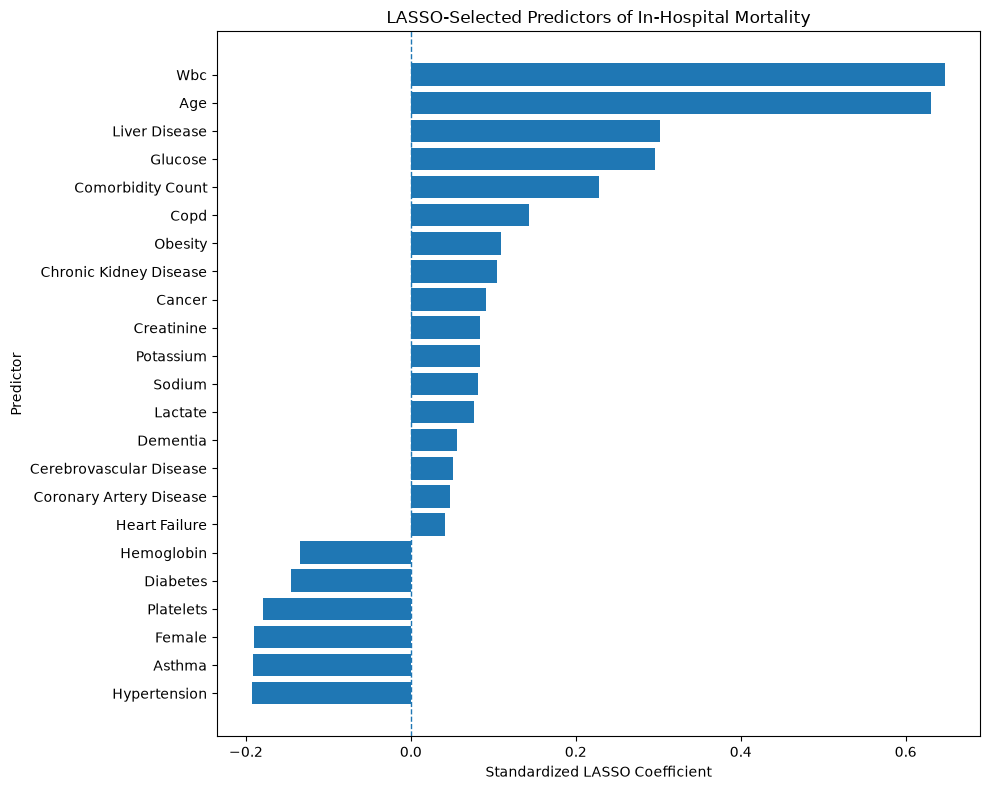

In [30]:
# 16. LASSO Coefficient Plot

print("\n[16] Creating LASSO coefficient plot...")

plot_data = lasso_selected.sort_values()

pretty_names = {
    x: x.replace("first24h_first_", "")
        .replace("_", " ")
        .title()
    for x in plot_data.index
}

plot_labels = [
    pretty_names[x]
    for x in plot_data.index
]

plt.figure(figsize=(10, 8))

plt.barh(
    plot_labels,
    plot_data.values
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Standardized LASSO Coefficient")
plt.ylabel("Predictor")
plt.title(
    "LASSO-Selected Predictors of In-Hospital Mortality"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "LASSO_Coefficient_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [31]:
# 17. XGBoost

import xgboost

print("\n[17] Training XGBoost...")

from xgboost import XGBClassifier

xgb_imputer = SimpleImputer(strategy="median")

X_train_xgb = pd.DataFrame(
    xgb_imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_xgb = pd.DataFrame(
    xgb_imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count / positive_count
)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_xgb,
    y_train
)

xgb_probability = (
    xgb_model.predict_proba(
        X_test_xgb
    )[:, 1]
)



[17] Training XGBoost...


In [32]:
# 18. Compare Logistic Regression, LASSO, and XGBoost

print("\n[18] Comparing model performance...")

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix
)

def evaluate_model(
    name,
    y_true,
    probability,
    threshold=0.50
):
    prediction = (
        probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    accuracy = accuracy_score(
        y_true,
        prediction
    )
    auc = roc_auc_score(
        y_true,
        probability
    )

    return {
        "Model": name,
        "ROC_AUC": auc,
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity
    }

model_results = pd.DataFrame(
    [
        evaluate_model(
            "Logistic Regression",
            y_test,
            logistic_probability
        ),
        evaluate_model(
            "LASSO",
            y_test,
            lasso_probability
        ),
        evaluate_model(
            "XGBoost",
            y_test,
            xgb_probability
        )
    ]
)

model_results.to_csv(
    TABLE_DIR / "Model_Comparison.csv",
    index=False
)

print(model_results.to_string(index=False))



[18] Comparing model performance...
              Model  ROC_AUC  Accuracy  Sensitivity  Specificity
Logistic Regression 0.767905  0.696482     0.669903     0.699552
              LASSO 0.767948  0.696482     0.669903     0.699552
            XGBoost 0.815828  0.796985     0.640777     0.815022


In [37]:
# 19. McFadden Pseudo R-Squared

print("\n[19] Calculating McFadden pseudo R-squared...")

from sklearn.metrics import log_loss


def mcfadden_r2(y_true, probabilities):
    """
    Calculate McFadden's pseudo R-squared.

    R²_McFadden = 1 - (log-likelihood fitted model /
                       log-likelihood null model)

    Note:
    For Logistic Regression and LASSO logistic regression, this is a
    conventional pseudo-R² measure. For XGBoost, the same log-loss-based
    calculation is included as a McFadden-style comparison metric.
    """

    y_true = np.asarray(y_true)
    probabilities = np.asarray(probabilities)

    # Avoid log(0).
    probabilities = np.clip(
        probabilities,
        1e-15,
        1 - 1e-15
    )

    # Fitted-model log-likelihood.
    ll_model = -log_loss(
        y_true,
        probabilities,
        normalize=False
    )

    # Null model predicts the observed mortality prevalence.
    null_probability = np.repeat(
        y_true.mean(),
        len(y_true)
    )

    ll_null = -log_loss(
        y_true,
        null_probability,
        normalize=False
    )

    pseudo_r2 = 1 - (
        ll_model / ll_null
    )

    return pseudo_r2


# ------------------------------------------------------------
# Calculate pseudo R-squared for all three models
# ------------------------------------------------------------

logistic_mcfadden = mcfadden_r2(
    y_test,
    logistic_probability
)

lasso_mcfadden = mcfadden_r2(
    y_test,
    lasso_probability
)

xgb_mcfadden = mcfadden_r2(
    y_test,
    xgb_probability
)


mcfadden_dict = {
    "Logistic Regression": logistic_mcfadden,
    "LASSO": lasso_mcfadden,
    "XGBoost": xgb_mcfadden
}


# ------------------------------------------------------------
# Add McFadden R² and percentage to the existing comparison table
# ------------------------------------------------------------

model_results["McFadden_R2"] = (
    model_results["Model"]
    .map(mcfadden_dict)
)

model_results["McFadden_R2_Percent"] = (
    model_results["McFadden_R2"]
    * 100
)


print("\nModel Performance Including McFadden Pseudo R-Squared:")
print(
    model_results.round(3).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Save updated model comparison table
# ------------------------------------------------------------

model_results.to_csv(
    TABLE_DIR / "Model_Comparison_With_McFadden_R2.csv",
    index=False
)


# ------------------------------------------------------------
# Separate McFadden results table
# ------------------------------------------------------------

mcfadden_results = model_results[
    [
        "Model",
        "McFadden_R2",
        "McFadden_R2_Percent"
    ]
].copy()

mcfadden_results.to_csv(
    TABLE_DIR / "McFadden_Pseudo_R2.csv",
    index=False
)

print("\nMcFadden Pseudo R-Squared:")
print(
    mcfadden_results.round(3).to_string(
        index=False
    )
)



[19] Calculating McFadden pseudo R-squared...

Model Performance Including McFadden Pseudo R-Squared:
              Model  ROC_AUC  Accuracy  Sensitivity  Specificity  McFadden_R2  McFadden_R2_Percent
Logistic Regression    0.768     0.696        0.670        0.700       -0.745              -74.534
              LASSO    0.768     0.696        0.670        0.700       -0.746              -74.585
            XGBoost    0.816     0.797        0.641        0.815       -0.302              -30.222

McFadden Pseudo R-Squared:
              Model  McFadden_R2  McFadden_R2_Percent
Logistic Regression       -0.745              -74.534
              LASSO       -0.746              -74.585
            XGBoost       -0.302              -30.222



[19] Creating ROC curve comparison...


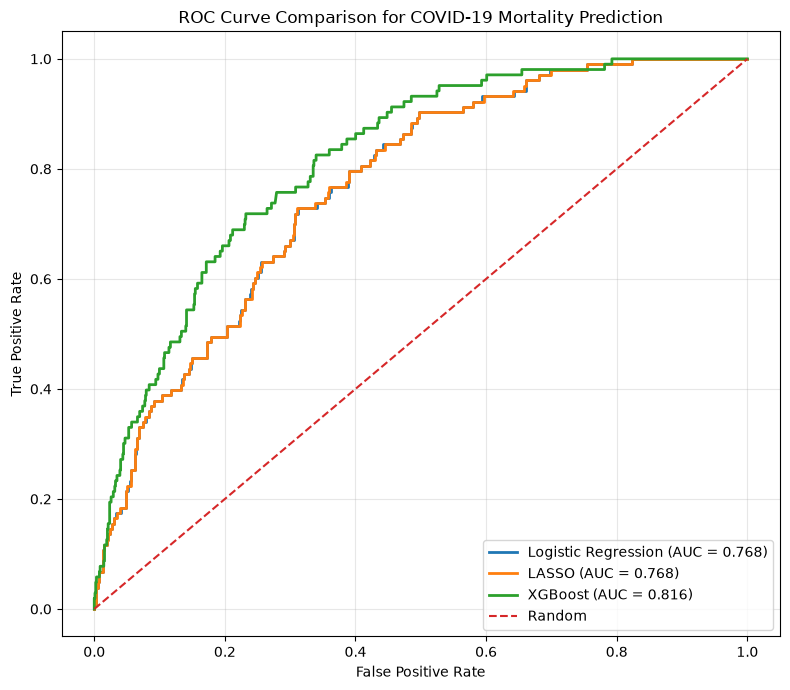

In [39]:
# 20. ROC Curve Comparison

print("\n[19] Creating ROC curve comparison...")

from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 7))

models_for_roc = {
    "Logistic Regression": logistic_probability,
    "LASSO": lasso_probability,
    "XGBoost": xgb_probability
}

for model_name, probability in models_for_roc.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    auc = roc_auc_score(
        y_test,
        probability
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "ROC Curve Comparison for COVID-19 Mortality Prediction"
)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "ROC_Model_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



[20] Creating XGBoost feature importance plot...


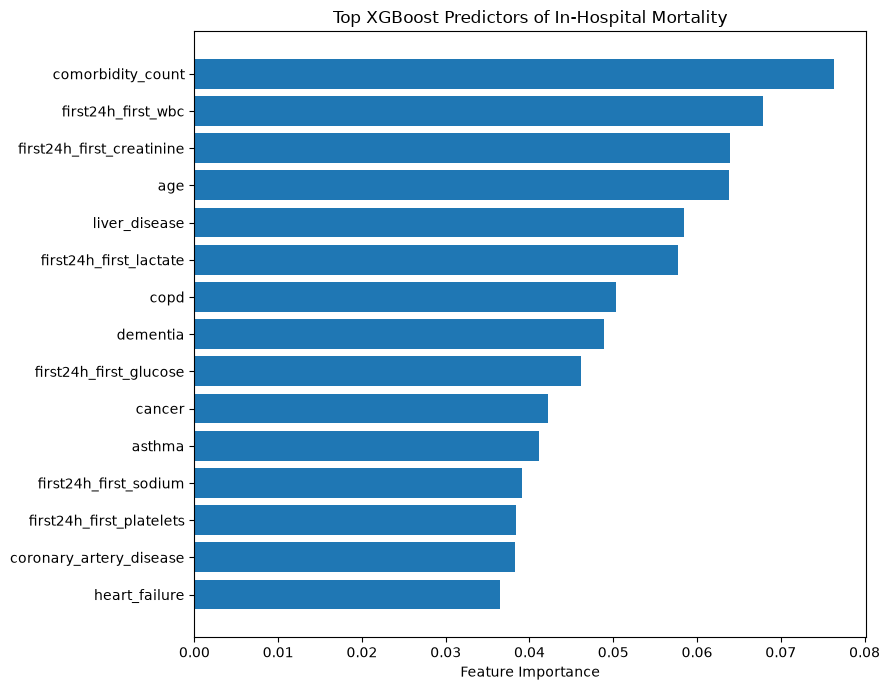

In [41]:
# 21. XGBoost Feature Importance

print("\n[20] Creating XGBoost feature importance plot...")

xgb_importance = pd.Series(
    xgb_model.feature_importances_,
    index=predictors
).sort_values(
    ascending=False
)

top_xgb = (
    xgb_importance
    .head(15)
    .sort_values()
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_xgb.index,
    top_xgb.values
)

plt.xlabel("Feature Importance")
plt.title(
    "Top XGBoost Predictors of In-Hospital Mortality"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "XGBoost_Feature_Importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [51]:
# 22. Prepare Data for Bayesian Network

from pgmpy.estimators import HillClimbSearch
from pgmpy.models import DiscreteBayesianNetwork

# Use LASSO-retained variables plus mortality outcome
bn_variables = (
    lasso_selected.index.tolist()
    + [outcome]
)

bn_variables = list(
    dict.fromkeys(bn_variables)
)

bn_df = model_df[
    bn_variables
].copy()


# ------------------------------------------------------------
# Variables already coded as binary
# ------------------------------------------------------------

binary_variables = {
    "female",
    "hypertension",
    "diabetes",
    "obesity",
    "copd",
    "asthma",
    "chronic_kidney_disease",
    "heart_failure",
    "coronary_artery_disease",
    "cancer",
    "liver_disease",
    "cerebrovascular_disease",
    "dementia",
    outcome
}


# ------------------------------------------------------------
# Discretize continuous variables into Low / Medium / High
# ------------------------------------------------------------

def discretize_three_levels(series):

    numeric = pd.to_numeric(
        series,
        errors="coerce"
    )

    numeric = numeric.fillna(
        numeric.median()
    )

    if numeric.nunique() < 3:

        return (
            numeric
            .astype(str)
        )

    categories = pd.qcut(
        numeric,
        q=3,
        duplicates="drop"
    )

    codes = categories.cat.codes

    n_bins = (
        int(codes.max()) + 1
    )

    if n_bins == 3:

        mapping = {
            0: "Low",
            1: "Medium",
            2: "High"
        }

    elif n_bins == 2:

        mapping = {
            0: "Low",
            1: "High"
        }

    else:

        return (
            numeric
            .astype(str)
        )

    return (
        codes
        .map(mapping)
        .astype(str)
    )


for column in bn_df.columns:

    if column in binary_variables:

        bn_df[column] = (
            bn_df[column]
            .fillna(0)
            .astype(int)
            .astype(str)
        )

    else:

        bn_df[column] = (
            discretize_three_levels(
                bn_df[column]
            )
        )


print(
    "Bayesian network shape:",
    bn_df.shape
)

print(
    "Variables included:"
)

print(
    list(bn_df.columns)
)

Bayesian network shape: (3978, 24)
Variables included:
['first24h_first_wbc', 'age', 'liver_disease', 'first24h_first_glucose', 'comorbidity_count', 'hypertension', 'asthma', 'female', 'first24h_first_platelets', 'diabetes', 'copd', 'first24h_first_hemoglobin', 'obesity', 'chronic_kidney_disease', 'cancer', 'first24h_first_creatinine', 'first24h_first_potassium', 'first24h_first_sodium', 'first24h_first_lactate', 'dementia', 'cerebrovascular_disease', 'coronary_artery_disease', 'heart_failure', 'in_hospital_mortality']


In [53]:
# 23. Learn Bayesian Network Structure

print("\n[23] Learning Bayesian network structure...")

from pgmpy.estimators import HillClimbSearch

try:

    from pgmpy.estimators import BIC

    scoring_method = BIC(
        bn_df
    )

except ImportError:

    from pgmpy.estimators import BicScore

    scoring_method = BicScore(
        bn_df
    )


search = HillClimbSearch(
    bn_df
)


learned_model = search.estimate(
    scoring_method=scoring_method,
    max_indegree=4,
    show_progress=True
)


learned_edges = list(
    learned_model.edges()
)


print(
    "\nLearned Bayesian Network Edges:"
)

for source, target in learned_edges:

    print(
        f"{source} -> {target}"
    )


pd.DataFrame(
    learned_edges,
    columns=[
        "From",
        "To"
    ]
).to_csv(
    TABLE_DIR
    / "Bayesian_Network_Edges.csv",
    index=False
)


[23] Learning Bayesian network structure...


  0%|          | 0/1000000 [00:00<?, ?it/s]


Learned Bayesian Network Edges:
first24h_first_wbc -> first24h_first_hemoglobin
first24h_first_wbc -> first24h_first_lactate
age -> dementia
age -> asthma
age -> in_hospital_mortality
first24h_first_glucose -> first24h_first_platelets
first24h_first_glucose -> first24h_first_creatinine
first24h_first_glucose -> diabetes
first24h_first_glucose -> first24h_first_lactate
first24h_first_glucose -> comorbidity_count
first24h_first_glucose -> obesity
first24h_first_glucose -> first24h_first_wbc
comorbidity_count -> hypertension
comorbidity_count -> diabetes
comorbidity_count -> heart_failure
comorbidity_count -> coronary_artery_disease
comorbidity_count -> copd
comorbidity_count -> cerebrovascular_disease
comorbidity_count -> liver_disease
comorbidity_count -> asthma
comorbidity_count -> cancer
hypertension -> age
hypertension -> liver_disease
hypertension -> copd
asthma -> copd
asthma -> cerebrovascular_disease
female -> obesity
first24h_first_platelets -> first24h_first_wbc
first24h_first

In [55]:
# 24. Markov Blanket and Parent Analysis

print("\n[24] Identifying Markov blanket of mortality...")

target = outcome


# ------------------------------------------------------------
# Parents of mortality
# ------------------------------------------------------------

parents = set(
    learned_model.predecessors(
        target
    )
)


# ------------------------------------------------------------
# Children of mortality
# ------------------------------------------------------------

children = set(
    learned_model.successors(
        target
    )
)


# ------------------------------------------------------------
# Spouses:
# Other parents of mortality's children
# ------------------------------------------------------------

spouses = set()

for child in children:

    child_parents = set(
        learned_model.predecessors(
            child
        )
    )

    spouses.update(
        child_parents
        - {target}
    )


# ------------------------------------------------------------
# Complete Markov blanket
# ------------------------------------------------------------

markov_blanket = (
    parents
    | children
    | spouses
)


print(
    "\nParents of Mortality:"
)

for variable in sorted(parents):

    print(
        " -",
        variable
    )


print(
    "\nChildren of Mortality:"
)

for variable in sorted(children):

    print(
        " -",
        variable
    )


print(
    "\nSpouses of Mortality:"
)

for variable in sorted(spouses):

    print(
        " -",
        variable
    )


print(
    "\nComplete Markov Blanket:"
)

for variable in sorted(markov_blanket):

    print(
        " -",
        variable
    )


# Save table
markov_results = pd.DataFrame(
    {
        "Relationship": [
            "Parents",
            "Children",
            "Spouses",
            "Complete Markov Blanket"
        ],

        "Variables": [
            ", ".join(
                sorted(parents)
            ),

            ", ".join(
                sorted(children)
            ),

            ", ".join(
                sorted(spouses)
            ),

            ", ".join(
                sorted(markov_blanket)
            )
        ]
    }
)


markov_results.to_csv(
    TABLE_DIR
    / "Markov_Blanket_Results.csv",
    index=False
)


[24] Identifying Markov blanket of mortality...

Parents of Mortality:
 - age
 - first24h_first_creatinine

Children of Mortality:

Spouses of Mortality:

Complete Markov Blanket:
 - age
 - first24h_first_creatinine



[25] Creating Markov blanket visualization...
Markov blanket nodes: ['age', 'in_hospital_mortality', 'first24h_first_creatinine']
Markov blanket edges: [('age', 'in_hospital_mortality'), ('first24h_first_creatinine', 'in_hospital_mortality')]

Markov Blanket Summary
Parents: ['age', 'first24h_first_creatinine']
Children: []
Spouses: []
Complete Markov Blanket: ['age', 'first24h_first_creatinine']


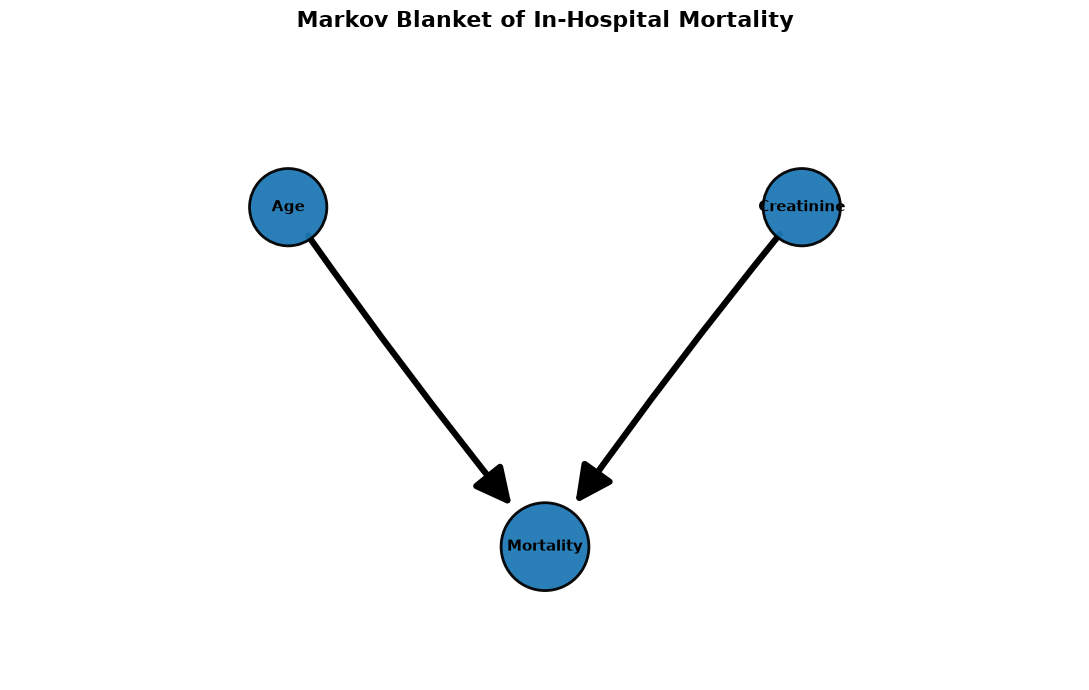

In [61]:
# 25. Visualize Markov Blanket

print("\n[25] Creating Markov blanket visualization...")

# ------------------------------------------------------------
# Build Markov blanket subgraph
# ------------------------------------------------------------

mb_nodes = (
    set(markov_blanket)
    | {outcome}
)

mb_graph = (
    learned_model
    .subgraph(mb_nodes)
    .copy()
)

print(
    "Markov blanket nodes:",
    list(mb_graph.nodes())
)

print(
    "Markov blanket edges:",
    list(mb_graph.edges())
)


# ------------------------------------------------------------
# Clean display labels
# ------------------------------------------------------------

mb_labels = {
    node: (
        node
        .replace(
            "first24h_first_",
            ""
        )
        .replace(
            "_",
            " "
        )
        .title()
    )
    for node in mb_graph.nodes()
}

mb_labels[outcome] = "Mortality"


# ------------------------------------------------------------
# Separate mortality from the other Markov blanket variables
# ------------------------------------------------------------

nodes_other_than_outcome = [
    node
    for node in mb_graph.nodes()
    if node != outcome
]


# ------------------------------------------------------------
# Create stable manual positions
# ------------------------------------------------------------

mb_positions = {}

# Put mortality at bottom center
mb_positions[outcome] = (
    0,
    -0.4
)


# One Markov blanket variable
if len(nodes_other_than_outcome) == 1:

    mb_positions[
        nodes_other_than_outcome[0]
    ] = (
        0,
        2.4
    )


# Two Markov blanket variables
elif len(nodes_other_than_outcome) == 2:

    mb_positions[
        nodes_other_than_outcome[0]
    ] = (
        -2.4,
        2.4
    )

    mb_positions[
        nodes_other_than_outcome[1]
    ] = (
        2.4,
        2.4
    )


# Three Markov blanket variables
elif len(nodes_other_than_outcome) == 3:

    mb_positions[
        nodes_other_than_outcome[0]
    ] = (
        -2.8,
        2.2
    )

    mb_positions[
        nodes_other_than_outcome[1]
    ] = (
        0,
        2.8
    )

    mb_positions[
        nodes_other_than_outcome[2]
    ] = (
        2.8,
        2.2
    )


# More than three variables
else:

    x_positions = np.linspace(
        -4,
        4,
        len(nodes_other_than_outcome)
    )

    for node, x in zip(
        nodes_other_than_outcome,
        x_positions
    ):

        mb_positions[node] = (
            x,
            2.5
        )


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(
    figsize=(11, 7)
)


# ------------------------------------------------------------
# Node sizes
# ------------------------------------------------------------

node_sizes = [
    4000
    if node == outcome
    else 3100
    for node in mb_graph.nodes()
]


# ------------------------------------------------------------
# Draw nodes
# ------------------------------------------------------------

nx.draw_networkx_nodes(
    mb_graph,
    pos=mb_positions,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=2.0,
    alpha=0.95
)


# ------------------------------------------------------------
# Draw highly visible arrows
# ------------------------------------------------------------

mb_edges = list(
    mb_graph.edges()
)


if len(mb_edges) > 0:

    for source, target in mb_edges:

        # Safety check so NetworkX does not try
        # to draw a zero-length arrow.
        if (
            source in mb_positions
            and target in mb_positions
            and mb_positions[source]
            != mb_positions[target]
        ):

            nx.draw_networkx_edges(
                mb_graph,
                pos=mb_positions,
                edgelist=[
                    (source, target)
                ],

                # Large arrowhead
                arrows=True,
                arrowsize=55,

                # Strong arrow style
                arrowstyle="-|>",

                # Thick line
                width=4.5,

                # Dark and fully visible
                edge_color="black",
                alpha=1.0,

                # Keep arrow away from node centers
                min_source_margin=25,
                min_target_margin=38,

                # Almost straight, but avoids rendering issues
                connectionstyle="arc3,rad=0.02"
            )


# ------------------------------------------------------------
# Draw labels
# ------------------------------------------------------------

nx.draw_networkx_labels(
    mb_graph,
    pos=mb_positions,
    labels=mb_labels,
    font_size=11,
    font_weight="bold"
)


# ------------------------------------------------------------
# Add relationship labels underneath figure
# ------------------------------------------------------------

print("\nMarkov Blanket Summary")

print(
    "Parents:",
    sorted(parents)
)

print(
    "Children:",
    sorted(children)
)

print(
    "Spouses:",
    sorted(spouses)
)

print(
    "Complete Markov Blanket:",
    sorted(markov_blanket)
)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.title(
    "Markov Blanket of In-Hospital Mortality",
    fontsize=16,
    fontweight="bold",
    pad=25
)


# ------------------------------------------------------------
# Improve visible spacing
# ------------------------------------------------------------

plt.xlim(
    -5,
    5
)

plt.ylim(
    -1.5,
    3.6
)


plt.axis("off")

plt.tight_layout()


# ------------------------------------------------------------
# Save publication-quality figure
# ------------------------------------------------------------

plt.savefig(
    FIGURE_DIR
    / "Markov_Blanket.png",
    dpi=300,
    bbox_inches="tight"
)


# ------------------------------------------------------------
# Display in notebook
# ------------------------------------------------------------

plt.show()

In [63]:
# 26. Build Direct Predictor Network

print("\n[21] Building temporally ordered direct predictor network...")

direct_predictors = lasso_selected.index.tolist()

direct_network = nx.DiGraph()
direct_network.add_node(outcome)

for variable in direct_predictors:
    direct_network.add_node(variable)
    direct_network.add_edge(
        variable,
        outcome
    )

def get_binary_name(variable):
    if variable == "age":
        return "age_binary"

    if variable == "comorbidity_count":
        return "comorbidity_count_binary"

    if variable in tier_2:
        return variable + "_binary"

    return variable

tier_lookup = {}

for variable in tier_0:
    tier_lookup[variable] = 0

for variable in tier_1:
    tier_lookup[variable] = 1

for variable in tier_2:
    tier_lookup[variable] = 2

tier_lookup[outcome] = 3

significant_pairwise = pairwise_results[
    (pairwise_results["P_Value"] < 0.05)
    &
    (
        (pairwise_results["Odds_Ratio"] >= 1.5)
        |
        (pairwise_results["Odds_Ratio"] <= 0.67)
    )
].copy()

for source in direct_predictors:
    for target in direct_predictors:

        if source == target:
            continue

        if (
            tier_lookup.get(source, 99)
            >= tier_lookup.get(target, -1)
        ):
            continue

        source_binary = get_binary_name(source)
        target_binary = get_binary_name(target)

        match = significant_pairwise[
            (
                (
                    significant_pairwise["Variable_1"]
                    == source_binary
                )
                &
                (
                    significant_pairwise["Variable_2"]
                    == target_binary
                )
            )
            |
            (
                (
                    significant_pairwise["Variable_1"]
                    == target_binary
                )
                &
                (
                    significant_pairwise["Variable_2"]
                    == source_binary
                )
            )
        ]

        if not match.empty:
            direct_network.add_edge(
                source,
                target
            )

print("Network nodes:", direct_network.number_of_nodes())
print("Network edges:", direct_network.number_of_edges())



[21] Building temporally ordered direct predictor network...
Network nodes: 24
Network edges: 70



[22] Creating direct predictor network visualization...


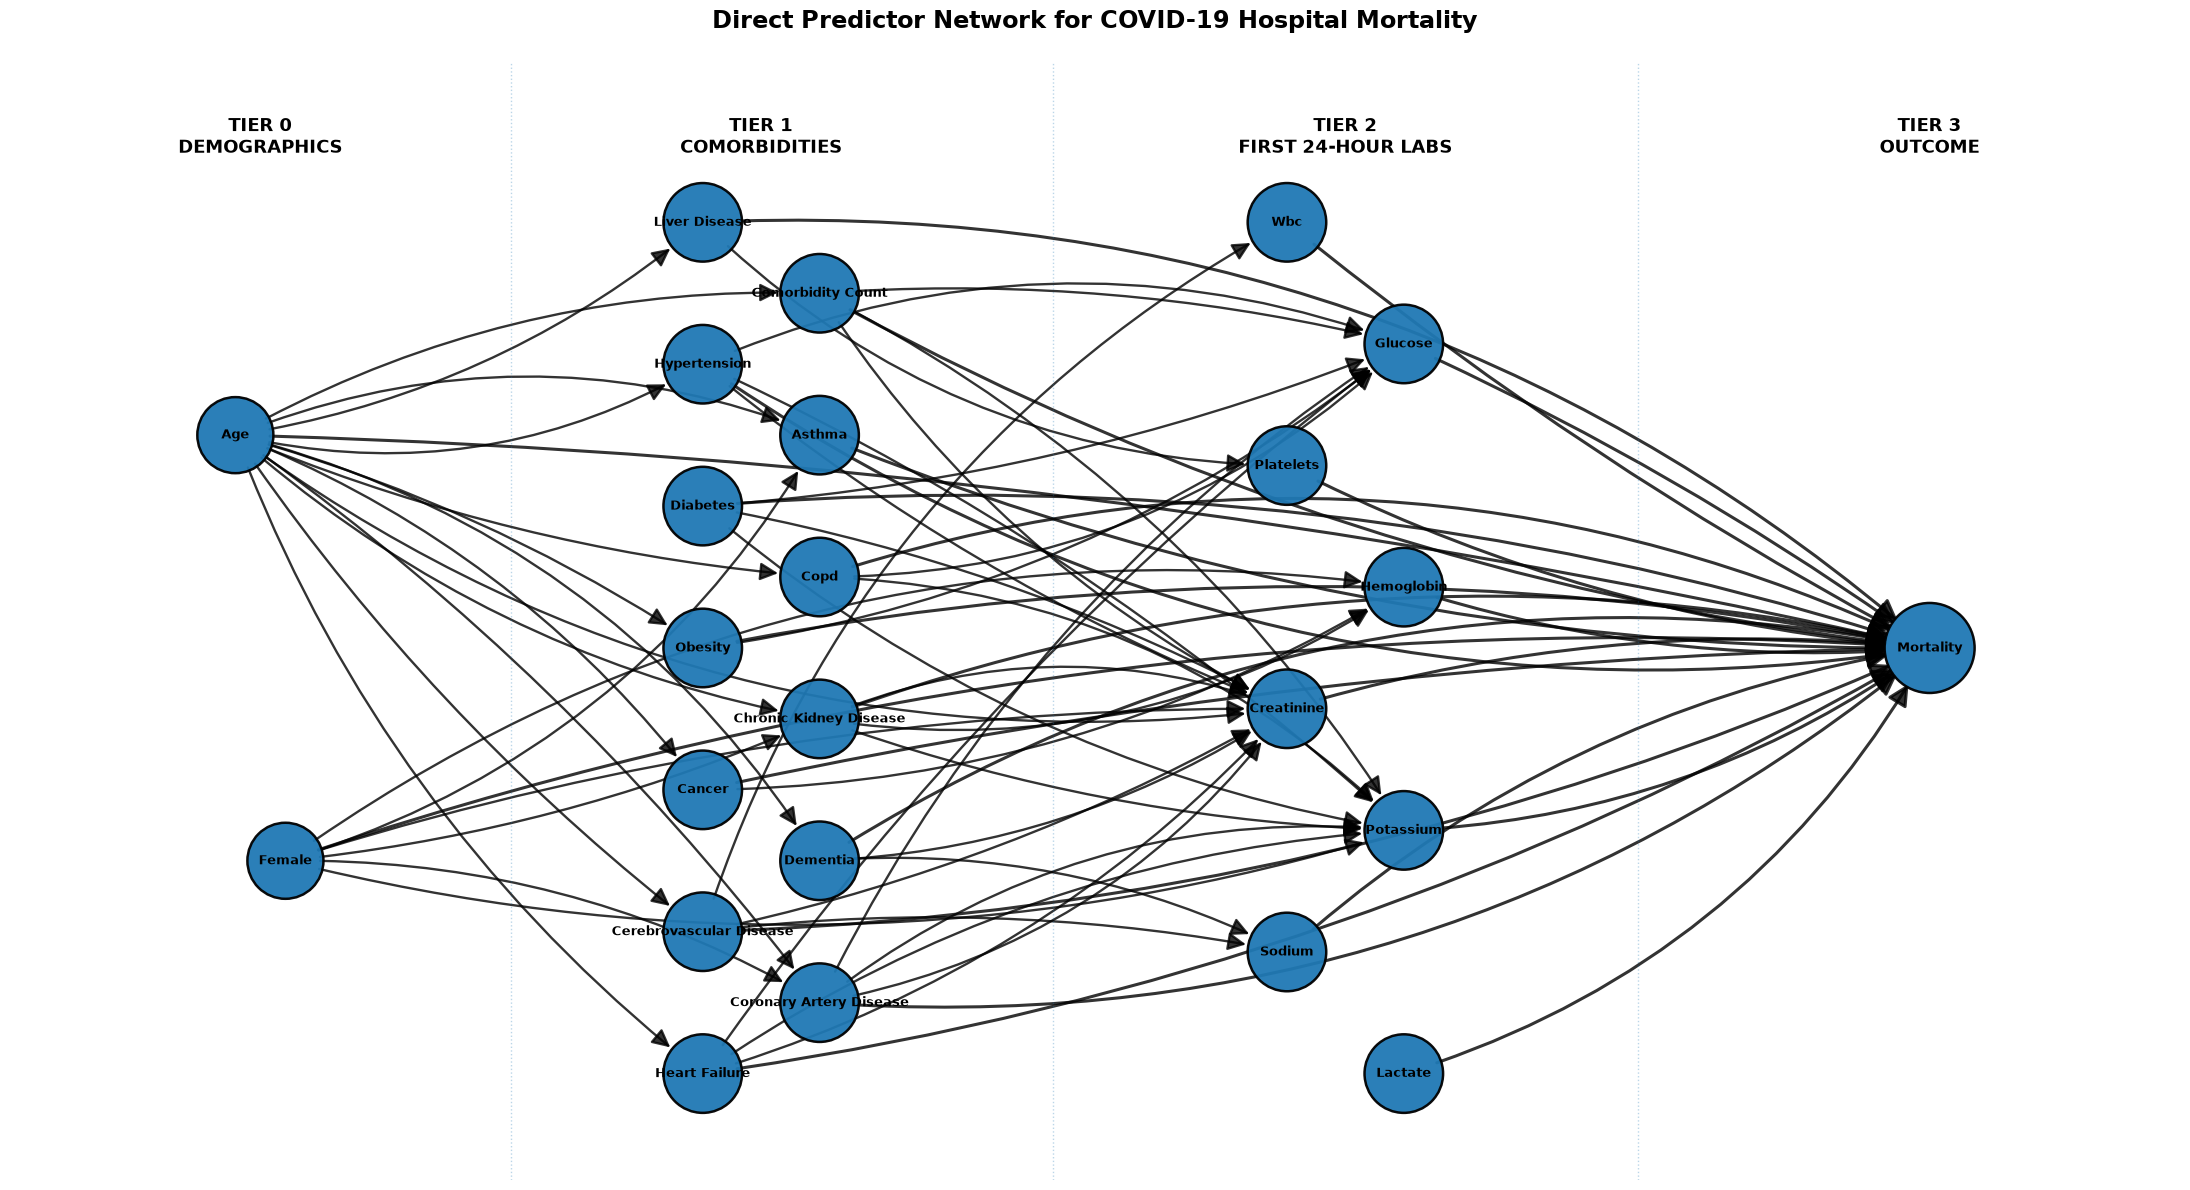

In [65]:
# 27. Visualize Direct Predictor Network

print("\n[22] Creating direct predictor network visualization...")

# ------------------------------------------------------------
# Organize selected predictors by temporal tier
# ------------------------------------------------------------

selected_tier_0 = [
    x for x in direct_predictors
    if x in tier_0
]

selected_tier_1 = [
    x for x in direct_predictors
    if x in tier_1
]

selected_tier_2 = [
    x for x in direct_predictors
    if x in tier_2
]


# ------------------------------------------------------------
# Create spaced vertical positions for each tier
# ------------------------------------------------------------

def make_staggered_positions(
    variables,
    center_x,
    y_top=3.5,
    y_bottom=-3.5,
    stagger=0.30
):
    if len(variables) == 0:
        return {}

    if len(variables) == 1:
        return {
            variables[0]: (center_x, 0)
        }

    ys = np.linspace(
        y_top,
        y_bottom,
        len(variables)
    )

    positions = {}

    for i, (variable, y) in enumerate(
        zip(variables, ys)
    ):

        # Slight horizontal staggering prevents nodes
        # and arrows from sitting directly on top of each other.
        if i % 2 == 0:
            x = center_x - stagger
        else:
            x = center_x + stagger

        positions[variable] = (x, y)

    return positions


positions = {}

positions.update(
    make_staggered_positions(
        selected_tier_0,
        center_x=0,
        y_top=2.0,
        y_bottom=-2.0,
        stagger=0.15
    )
)

positions.update(
    make_staggered_positions(
        selected_tier_1,
        center_x=3.0,
        y_top=4.0,
        y_bottom=-4.0,
        stagger=0.35
    )
)

positions.update(
    make_staggered_positions(
        selected_tier_2,
        center_x=6.5,
        y_top=4.0,
        y_bottom=-4.0,
        stagger=0.35
    )
)

positions[outcome] = (10.0, 0)


# ------------------------------------------------------------
# Cleaner display labels
# ------------------------------------------------------------

pretty_labels = {
    x: (
        x.replace("first24h_first_", "")
        .replace("_", " ")
        .title()
    )
    for x in direct_network.nodes()
}

pretty_labels[outcome] = "Mortality"


# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

plt.figure(figsize=(22, 12))


# ------------------------------------------------------------
# Draw nodes
# ------------------------------------------------------------

node_sizes = []

for node in direct_network.nodes():

    if node == outcome:
        node_sizes.append(4200)

    elif node in selected_tier_0:
        node_sizes.append(3000)

    else:
        node_sizes.append(3200)


nx.draw_networkx_nodes(
    direct_network,
    positions,
    node_size=node_sizes,
    edgecolors="black",
    linewidths=1.8,
    alpha=0.95
)


# ------------------------------------------------------------
# Draw EACH edge separately
#
# Giving each edge a slightly different curvature prevents
# multiple arrows from lying directly on top of one another.
# ------------------------------------------------------------

edges = list(
    direct_network.edges()
)

for i, (source, target) in enumerate(edges):

    # --------------------------------------------------------
    # Edges going directly to mortality
    # --------------------------------------------------------

    if target == outcome:

        # Alternate curves above and below the center line.
        curve_options = [
            0.05,
            -0.05,
            0.10,
            -0.10,
            0.15,
            -0.15,
            0.20,
            -0.20
        ]

        curve = curve_options[
            i % len(curve_options)
        ]

        edge_width = 2.2
        arrow_size = 32

    # --------------------------------------------------------
    # Connections between predictor tiers
    # --------------------------------------------------------

    else:

        curve_options = [
            0.08,
            -0.08,
            0.14,
            -0.14,
            0.20,
            -0.20
        ]

        curve = curve_options[
            i % len(curve_options)
        ]

        edge_width = 1.7
        arrow_size = 27


    nx.draw_networkx_edges(
        direct_network,
        positions,
        edgelist=[
            (source, target)
        ],
        arrows=True,
        arrowsize=arrow_size,
        arrowstyle="-|>",
        width=edge_width,

        # Curves overlapping arrows
        connectionstyle=(
            f"arc3,rad={curve}"
        ),

        # Keep arrows outside nodes
        min_source_margin=25,
        min_target_margin=30,

        alpha=0.80
    )


# ------------------------------------------------------------
# Draw labels
# ------------------------------------------------------------

nx.draw_networkx_labels(
    direct_network,
    positions,
    labels=pretty_labels,
    font_size=9,
    font_weight="bold"
)


# ------------------------------------------------------------
# Add temporal-tier headings
# ------------------------------------------------------------

heading_y = 4.8

plt.text(
    0,
    heading_y,
    "TIER 0\nDEMOGRAPHICS",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

plt.text(
    3.0,
    heading_y,
    "TIER 1\nCOMORBIDITIES",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

plt.text(
    6.5,
    heading_y,
    "TIER 2\nFIRST 24-HOUR LABS",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)

plt.text(
    10.0,
    heading_y,
    "TIER 3\nOUTCOME",
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)


# ------------------------------------------------------------
# Add subtle vertical separators between tiers
# ------------------------------------------------------------

plt.axvline(
    x=1.5,
    linestyle=":",
    linewidth=1,
    alpha=0.3
)

plt.axvline(
    x=4.75,
    linestyle=":",
    linewidth=1,
    alpha=0.3
)

plt.axvline(
    x=8.25,
    linestyle=":",
    linewidth=1,
    alpha=0.3
)


# ------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------

plt.title(
    "Direct Predictor Network for COVID-19 Hospital Mortality",
    fontsize=17,
    fontweight="bold",
    pad=25
)

plt.xlim(
    -1.5,
    11.5
)

plt.ylim(
    -5,
    5.5
)

plt.axis("off")

plt.tight_layout()


# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

plt.savefig(
    FIGURE_DIR / "Direct_Predictor_Network.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [67]:
# 28. Plain-Language Results Summary

print("\n[23] Generating plain-language summary...")

best_model_row = (
    model_results
    .sort_values(
        "ROC_AUC",
        ascending=False
    )
    .iloc[0]
)

best_model = best_model_row["Model"]
best_auc = best_model_row["ROC_AUC"]

top_lasso = (
    lasso_selected
    .head(5)
    .index
    .tolist()
)

pretty_top = [
    variable
    .replace("first24h_first_", "")
    .replace("_", " ")
    .title()
    for variable in top_lasso
]

summary = f"""
This study analyzed in-hospital mortality among patients
hospitalized with COVID-19 in MIMIC-IV.

Logistic regression, LASSO logistic regression, and XGBoost
were compared for mortality prediction.

The best-performing model was {best_model},
with an ROC AUC of {best_auc:.3f}.

LASSO identified {len(lasso_selected)} direct mortality
predictors. The strongest selected variables included:

{", ".join(pretty_top)}.

The temporally ordered predictor network shows how
demographic characteristics, pre-existing comorbidities,
and first 24-hour laboratory measurements relate to the
hospital mortality outcome.
"""

print(summary)



[23] Generating plain-language summary...

This study analyzed in-hospital mortality among patients
hospitalized with COVID-19 in MIMIC-IV.

Logistic regression, LASSO logistic regression, and XGBoost
were compared for mortality prediction.

The best-performing model was XGBoost,
with an ROC AUC of 0.816.

LASSO identified 23 direct mortality
predictors. The strongest selected variables included:

Wbc, Age, Liver Disease, Glucose, Comorbidity Count.

The temporally ordered predictor network shows how
demographic characteristics, pre-existing comorbidities,
and first 24-hour laboratory measurements relate to the
hospital mortality outcome.



In [71]:
# 30. Final Results Summary

print("\n" + "=" * 80)
print("FINAL PROJECT RESULTS SUMMARY")
print("=" * 80)

print(f"COVID-19 admissions: {len(covid_table):,}")
print(f"Unique patients: {covid_table['subject_id'].nunique():,}")

print(
    "In-hospital deaths: "
    f"{int(covid_table['in_hospital_mortality'].sum()):,} "
    f"({covid_table['in_hospital_mortality'].mean() * 100:.1f}%)"
)

print("Final candidate predictors:", len(predictors))
print("LASSO-selected predictors:", len(lasso_selected))

print("\nModel Comparison:")
print(model_results.to_string(index=False))

print("\nMcFadden Pseudo R-Squared:")
print(mcfadden_results.round(3).to_string(index=False))

print("\nTop LASSO Predictors:")
print(lasso_selected.head(10).to_string())

print("\nTop XGBoost Predictors:")
print(xgb_importance.head(10).to_string())

print("\nGenerated figures:", FIGURE_DIR.resolve())
print("Generated tables:", TABLE_DIR.resolve())
print("Analytical dataset:", ANALYTIC_DATA_FILE.resolve())
print("=" * 80)



FINAL PROJECT RESULTS SUMMARY
COVID-19 admissions: 3,978
Unique patients: 3,620
In-hospital deaths: 412 (10.4%)
Final candidate predictors: 23
LASSO-selected predictors: 23

Model Comparison:
              Model  ROC_AUC  Accuracy  Sensitivity  Specificity  McFadden_R2  McFadden_R2_Percent
Logistic Regression 0.767905  0.696482     0.669903     0.699552    -0.745341           -74.534141
              LASSO 0.767948  0.696482     0.669903     0.699552    -0.745848           -74.584782
            XGBoost 0.815828  0.796985     0.640777     0.815022    -0.302221           -30.222083

McFadden Pseudo R-Squared:
              Model  McFadden_R2  McFadden_R2_Percent
Logistic Regression       -0.745              -74.534
              LASSO       -0.746              -74.585
            XGBoost       -0.302              -30.222

Top LASSO Predictors:
first24h_first_wbc          0.648096
age                         0.630968
liver_disease               0.301731
first24h_first_glucose      0.295